<h1 align="center">Task 2 — Model Development Using Linear Regression</h1>

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [12]:
%pip install scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Data ingestion only 2nd sheet in Excel . So mention that sheet name here .
df=pd.read_excel(r"C:\Users\ELCOT\Desktop\JananiMurugan\Machine_Learning\Dataset\ML_data1.xlsx",sheet_name="Model_Dev")
df

,Student_ID,Department,Attendance,Study_Hours,Assignment_Score,Internal_Marks,Previous_GPA,Backlogs,Library_Hours,Final_Score,Pass_Fail
0,1001,CSE,92,8.0,88,82,8.6,0,6,87,Pass
1,1002,IT,76,5.0,72,68,7.2,1,3,71,Pass
2,1003,ECE,61,3.5,55,52,6.4,3,1,54,Fail
3,1004,AI&DS,95,9.0,94,91,9.1,0,8,93,Pass
4,1005,BBA,68,4.0,61,58,6.8,2,2,60,Pass


## Data Quality Check

In [3]:
# To check null values
df.isnull().sum()

Student_ID          0
Department          0
Attendance          0
Study_Hours         0
Assignment_Score    0
Internal_Marks      0
Previous_GPA        0
Backlogs            0
Library_Hours       0
Final_Score         0
Pass_Fail           0
dtype: int64

In [4]:
# To  check duplicate  values
df.duplicated().sum()

np.int64(0)

In [5]:
df.head(3)

,Student_ID,Department,Attendance,Study_Hours,Assignment_Score,Internal_Marks,Previous_GPA,Backlogs,Library_Hours,Final_Score,Pass_Fail
0,1001,CSE,92,8.0,88,82,8.6,0,6,87,Pass
1,1002,IT,76,5.0,72,68,7.2,1,3,71,Pass
2,1003,ECE,61,3.5,55,52,6.4,3,1,54,Fail


In [6]:
df.tail(-2)

,Student_ID,Department,Attendance,Study_Hours,Assignment_Score,Internal_Marks,Previous_GPA,Backlogs,Library_Hours,Final_Score,Pass_Fail
2,1003,ECE,61,3.5,55,52,6.4,3,1,54,Fail
3,1004,AI&DS,95,9.0,94,91,9.1,0,8,93,Pass
4,1005,BBA,68,4.0,61,58,6.8,2,2,60,Pass


In [7]:
# To check  how many rows and columns
df.shape

(5, 11)

## 1. Linear Regression
##### Feature and target selection

In [8]:
#  Extracting features without drop
# So  the following is  called as feature selection

X = df[
    ["Attendance",
    "Study_Hours",
    "Assignment_Score",
    "Internal_Marks",
    "Previous_GPA",
    "Backlogs",
    "Library_Hours"
    ]
]

# Select Target
y=df["Final_Score"]

In [9]:
# To view the selected features and target

pd.concat([X, y], axis=1)

,Attendance,Study_Hours,Assignment_Score,Internal_Marks,Previous_GPA,Backlogs,Library_Hours,Final_Score
0,92,8.0,88,82,8.6,0,6,87
1,76,5.0,72,68,7.2,1,3,71
2,61,3.5,55,52,6.4,3,1,54
3,95,9.0,94,91,9.1,0,8,93
4,68,4.0,61,58,6.8,2,2,60


## Train-Test Split
Split the data into training and testing sets.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size = 0.3,
    random_state = 43
)

In [11]:
# To view the shape of train and test sets

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# X_train (3, 7) → 3 rows × 7 features
# X_test (2, 7) → 2 rows × 7 features
# y_train (3,) → 3 Final_Score values
# y_test (2,) → 2 Final_Score values

X_train: (3, 7)
X_test: (2, 7)
y_train: (3,)
y_test: (2,)


## Linear Regression Model Development

##### (i) Model_Building & Training

In [36]:
model  = LinearRegression()

# .fit() = teach the model using training data
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](7,)","[ 0.1 ,-0.04, 0.49,...,-0.03,-0.07,-0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](7,)","['Attendance','Study_Hours','Assignment_Score',...,'Previous_GPA', 'Backlogs','Library_Hours']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.247
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,7
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


### (ii). Model Prediction

##### for testing model

In [37]:
y_pred = model.predict(X_test)
y_pred

array([94.42137455, 53.4547107 ])

In [38]:
# To cross compare the values
print("Actual: ", y_test.values)
print("Predicted: ", y_pred)

Actual:  [93 54]
Predicted:  [94.42137455 53.4547107 ]


#### Prediction for training model

In [39]:
# y_pred = model.predict(X_train)
# y_pred

In [40]:
# To cross compare the values
# print("Actual: ", y_train.values)
# print("Predicted: ", y_pred)

### (iii). Model Evaluation Metrics

###### 1. MAE

In [ ]:
mae = mean_absolute_error(y_test,y_pred)
print("MAE:", mae)
# MAE (Mean Absolute Error) → Finds the average difference between actual and predicted values. Lower MAE = better.

MAE: 0.9833319242750349


###### 2. RMSE

In [45]:
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
print("RMSE: ",  rmse)
# RMSE (Root Mean Squared Error) → Measures prediction error and gives more importance to larger errors. Lower RMSE = better.


RMSE:  1.0764864201658098


###### 3. r2 ERROR

In [ ]:
r2 = r2_score(y_test, y_pred)
print("R2_Score: " ,r2)
# R² Score → Shows how well the model explains the variation in the actual scores. Closer to 1 = better.

R2_Score:  0.9969524707092665


### Actual vs Predicted result

In [ ]:
results = pd.DataFrame({
    "Actual" : y_test,
    "Predicted" : y_pred
})
print(results)

   Actual  Predicted
3      93  94.421375
2      54  53.454711


#### Actual vs Predicted Plot

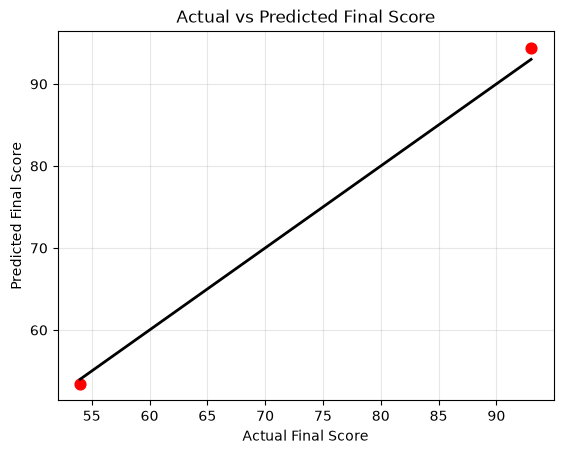

In [68]:
plt.scatter(y_test, y_pred, color="red", s=60)
plt.plot(y_test, y_test, color="black", linewidth=2)

plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")

plt.grid(True, alpha=0.3)
plt.show()